# 08 Single-Claim Inference Demo

This notebook loads the best-performing fine-tuned transformer model identified in `07_model_comparison_three_way.ipynb` and classifies a user-supplied health claim in real time, returning a **label** (`Reliable` / `Misinformation`) and a **confidence score**.

**Use cases:**
- Interactively test the model on new claims during development.
- Run batch inference on a custom list of claims.
- Demonstrate the system as part of a thesis defence or presentation.

**No re-training required** — the saved model weights from notebook 06 (or 04) are loaded directly.


## 1. Imports


In [1]:
from pathlib import Path
import json
import textwrap

import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification

C:\Users\ribam\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Paths and Device


In [2]:
PROJECT_ROOT = Path(r'C:\Users\ribam\Desktop\Reseach\Dataset')
OUTPUT_ROOT  = PROJECT_ROOT / 'output'
MODEL_ROOT   = PROJECT_ROOT / 'model'

# Map the model short-names used in the comparison notebooks to local saved-model directories.
MODEL_DIR_MAP = {
    'BioBERT'   : MODEL_ROOT / 'biobert_fakehealth_healthfact',
    'PubMedBERT': MODEL_ROOT / 'pubmedbert_fakehealth_healthfact',
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 3. Auto-Select the Best Model

Reads the `comparison_summary.json` written by notebook 07 and picks whichever transformer scored the highest test F1. If the summary file is not yet available (e.g. notebook 07 has not been run), the fallback can be set manually below.


In [3]:
SUMMARY_PATH = OUTPUT_ROOT / 'model_comparison_three_way' / 'comparison_summary.json'

# ── fallback: change this if you want to force a specific model ──
FALLBACK_MODEL = 'PubMedBERT'

if SUMMARY_PATH.exists():
    summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
    best_name = summary['best_model_by_test_f1']
    # TF-IDF is not a transformer — fall back to best available transformer
    if best_name not in MODEL_DIR_MAP:
        # pick the transformer with the highest F1 from the summary
        best_name = max(
            (m for m in summary['test_f1_scores'] if m in MODEL_DIR_MAP),
            key=lambda m: summary['test_f1_scores'][m],
        )
    print(f'Best model from summary : {best_name}')
    print(f'Test F1 scores          : {summary["test_f1_scores"]}')
else:
    best_name = FALLBACK_MODEL
    print(f'Summary file not found — using fallback: {best_name}')

BEST_MODEL_DIR = MODEL_DIR_MAP[best_name]
print(f'Loading from            : {BEST_MODEL_DIR}')

Best model from summary : BioBERT
Test F1 scores          : {'TF-IDF + Logistic Regression': 0.722222, 'BioBERT': 0.799079, 'PubMedBERT': 0.777994}
Loading from            : C:\Users\ribam\Desktop\Reseach\Dataset\model\biobert_fakehealth_healthfact


## 4. Load Tokenizer and Model


In [4]:
tokenizer = AutoTokenizer.from_pretrained(str(BEST_MODEL_DIR), use_fast=True)
model     = AutoModelForSequenceClassification.from_pretrained(str(BEST_MODEL_DIR))
model.to(DEVICE)
model.eval()

# Label mapping saved with the model during training
ID2LABEL = model.config.id2label   # {0: 'misinformation', 1: 'reliable'}
print('Labels:', ID2LABEL)
print('Model loaded and ready.')

Labels: {0: 'misinformation', 1: 'reliable'}
Model loaded and ready.


## 5. Inference Helper Functions


In [5]:
MAX_LENGTH = 256   # must match the value used during fine-tuning


def predict_claim(text: str) -> dict:
    """Classify a single health claim.

    Parameters
    ----------
    text : str
        The raw health claim or article snippet to classify.

    Returns
    -------
    dict with keys:
        label       – 'misinformation' or 'reliable'
        label_id    – 0 or 1
        confidence  – probability of the predicted class (0–1)
        prob_misinfo – probability of class 0
        prob_reliable – probability of class 1
    """
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True,
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    probs      = torch.softmax(logits, dim=-1).squeeze().cpu().tolist()
    label_id   = int(torch.argmax(logits, dim=-1).item())

    return {
        'label'         : ID2LABEL[label_id],
        'label_id'      : label_id,
        'confidence'    : round(probs[label_id], 4),
        'prob_misinfo'  : round(probs[0], 4),
        'prob_reliable' : round(probs[1], 4),
    }


def predict_batch(texts: list[str]) -> pd.DataFrame:
    """Classify a list of claims and return results as a DataFrame."""
    return pd.DataFrame([{'text': t, **predict_claim(t)} for t in texts])


def print_result(text: str, result: dict) -> None:
    """Pretty-print a single prediction result."""
    label_display = result['label'].upper()
    bar_filled    = int(result['confidence'] * 30)
    bar           = '█' * bar_filled + '░' * (30 - bar_filled)

    print('\n' + '─' * 72)
    print('CLAIM   :', textwrap.fill(text, width=68, subsequent_indent='          '))
    print('─' * 72)
    print(f'VERDICT : {label_display}')
    print(f'CONFIDENCE  [{bar}]  {result["confidence"] * 100:.1f}%')
    print(f'  prob_misinfo  = {result["prob_misinfo"]:.4f}')
    print(f'  prob_reliable = {result["prob_reliable"]:.4f}')
    print('─' * 72)


print('Helper functions defined.')

Helper functions defined.


## 6. Built-in Demo — Known Examples

A curated set of health claims drawn from the test set (with known ground-truth labels) to verify the model is working correctly before running your own inputs.


In [6]:
demo_examples = [
    # (text, ground_truth_label)
    (
        'Suicide kills one person every 40 seconds, says WHO report.',
        'reliable'
    ),
    (
        'A few drops of Visine brand eye drops taken internally can cause serious '
        'health problems including slowed heart rate, depression of the central '
        'nervous system, and other potentially dangerous effects.',
        'misinformation'
    ),
    (
        'Viral image says 80% of novel coronavirus cases are mild.',
        'reliable'
    ),
    (
        'NASA and NOAA faked climate data in the GISTEMP record to show '
        'temperatures warmer than they actually were.',
        'misinformation'
    ),
    (
        'Britain backs GSK gene therapy for bubble boy disease.',
        'reliable'
    ),
]

print(f'Running {len(demo_examples)} demo examples with {best_name}...\n')
for text, truth in demo_examples:
    result = predict_claim(text)
    print_result(text, result)
    match = '✓ CORRECT' if result['label'] == truth else '✗ WRONG'
    print(f'Ground truth: {truth.upper()}  →  {match}')

Running 5 demo examples with BioBERT...


────────────────────────────────────────────────────────────────────────
CLAIM   : Suicide kills one person every 40 seconds, says WHO report.
────────────────────────────────────────────────────────────────────────
VERDICT : RELIABLE
CONFIDENCE  [█████████████████████████████░]  99.7%
  prob_misinfo  = 0.0029
  prob_reliable = 0.9971
────────────────────────────────────────────────────────────────────────
Ground truth: RELIABLE  →  ✓ CORRECT

────────────────────────────────────────────────────────────────────────
CLAIM   : A few drops of Visine brand eye drops taken internally can cause
          serious health problems including slowed heart rate,
          depression of the central nervous system, and other
          potentially dangerous effects.
────────────────────────────────────────────────────────────────────────
VERDICT : MISINFORMATION
CONFIDENCE  [██████████████████░░░░░░░░░░░░]  61.0%
  prob_misinfo  = 0.6096
  prob_reliable = 0.3

## 7. Interactive Single-Claim Cell

**Edit `MY_CLAIM` below and run the cell** to classify any health claim of your choice.


In [7]:
# ── EDIT THIS ──────────────────────────────────────────────────────────────
MY_CLAIM = "Drinking bleach can cure COVID-19."
# ───────────────────────────────────────────────────────────────────────────

result = predict_claim(MY_CLAIM)
print_result(MY_CLAIM, result)


────────────────────────────────────────────────────────────────────────
CLAIM   : Drinking bleach can cure COVID-19.
────────────────────────────────────────────────────────────────────────
VERDICT : RELIABLE
CONFIDENCE  [███████████████████████████░░░]  91.9%
  prob_misinfo  = 0.0813
  prob_reliable = 0.9187
────────────────────────────────────────────────────────────────────────


## 8. Batch Inference on a Custom List

Add as many claims as you like to `custom_claims`. Results are printed and saved to a CSV.


In [8]:
# ── EDIT THIS LIST ─────────────────────────────────────────────────────────
custom_claims = [
    "Regular physical activity reduces the risk of heart disease.",
    "Vaccines cause autism in children.",
    "5G towers spread COVID-19 through electromagnetic waves.",
    "The FDA approved a new Alzheimer's drug that slows cognitive decline.",
    "Eating a teaspoon of turmeric daily cures all cancers.",
]
# ───────────────────────────────────────────────────────────────────────────

batch_df = predict_batch(custom_claims)
batch_df

,text,label,label_id,confidence,prob_misinfo,prob_reliable
0,Regular physical activity reduces the risk of ...,misinformation,0,0.7900,0.7900,0.2100
1,Vaccines cause autism in children.,reliable,1,0.9101,0.0899,0.9101
2,5G towers spread COVID-19 through electromagne...,reliable,1,0.9971,0.0029,0.9971
3,The FDA approved a new Alzheimer's drug that s...,misinformation,0,0.8410,0.8410,0.1590
4,Eating a teaspoon of turmeric daily cures all ...,misinformation,0,0.9127,0.9127,0.0873


In [9]:
INFER_OUT_DIR = PROJECT_ROOT / 'output' / 'inference'
INFER_OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = INFER_OUT_DIR / 'custom_claims_predictions.csv'
batch_df.to_csv(out_path, index=False)
print('Saved predictions to', out_path)

Saved predictions to C:\Users\ribam\Desktop\Reseach\Dataset\output\inference\custom_claims_predictions.csv


## 9. Confidence Distribution on the Full Test Set

Loads the saved test-set predictions from notebook 06 / 04 and plots the confidence histogram split by correct vs incorrect predictions, which is a useful figure for the thesis.


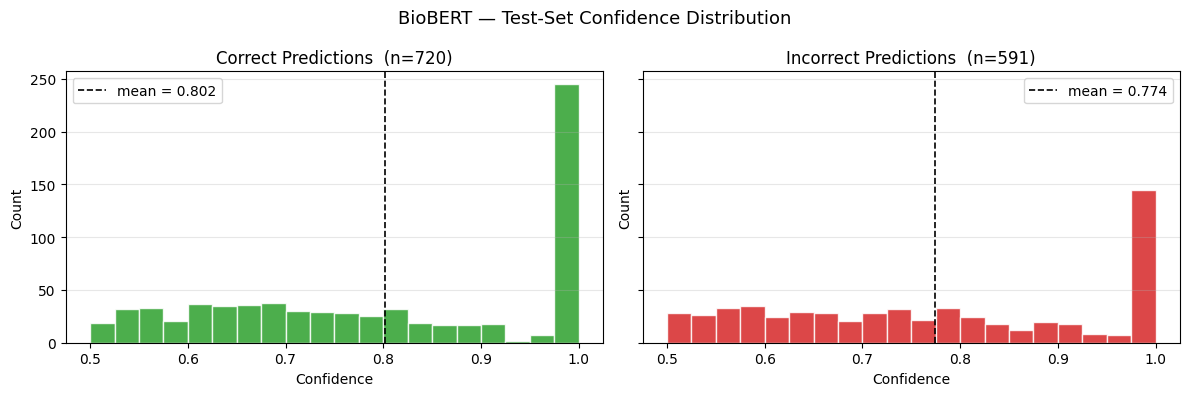

Saved confidence plot to C:\Users\ribam\Desktop\Reseach\Dataset\output\inference\biobert_confidence_distribution.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Map model name → prediction CSV written during training
PRED_CSV_MAP = {
    'BioBERT'   : OUTPUT_ROOT / 'biobert_fakehealth_healthfact'    / 'biobert_test_predictions.csv',
    'PubMedBERT': OUTPUT_ROOT / 'pubmedbert_fakehealth_healthfact'  / 'pubmedbert_test_predictions.csv',
}

pred_csv_path = PRED_CSV_MAP[best_name]
pred_df = pd.read_csv(pred_csv_path)

# confidence = probability of whichever class was predicted
pred_df['confidence'] = pred_df.apply(
    lambda r: r['prob_class_1'] if r['prediction'] == 1 else r['prob_class_0'],
    axis=1
)
pred_df['correct'] = pred_df['prediction'] == pred_df['label']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (correct, title, color) in zip(
    axes,
    [
        (True,  'Correct Predictions',   '#2ca02c'),
        (False, 'Incorrect Predictions', '#d62728'),
    ]
):
    subset = pred_df[pred_df['correct'] == correct]['confidence']
    ax.hist(subset, bins=20, range=(0.5, 1.0), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{title}  (n={len(subset)})')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.axvline(subset.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean = {subset.mean():.3f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(f'{best_name} — Test-Set Confidence Distribution', fontsize=13)
plt.tight_layout()

conf_plot_path = INFER_OUT_DIR / f'{best_name.lower().replace(" ", "_")}_confidence_distribution.png'
plt.savefig(conf_plot_path, dpi=150)
plt.show()
print('Saved confidence plot to', conf_plot_path)

## 10. Wrong-but-Confident Cases

High-confidence mistakes are the most informative failure mode — the model is wrong AND certain about it. These are strong candidates for the qualitative discussion in the thesis.


In [11]:
CONFIDENCE_THRESHOLD = 0.80   # adjust as needed

wrong_confident = (
    pred_df[~pred_df['correct'] & (pred_df['confidence'] >= CONFIDENCE_THRESHOLD)]
    [['dataset', 'record_id', 'label', 'prediction', 'confidence', 'text']]
    .sort_values('confidence', ascending=False)
    .reset_index(drop=True)
)

print(f'Wrong but confident (≥{CONFIDENCE_THRESHOLD:.0%}) : {len(wrong_confident)} examples')
wrong_confident.head(10)

Wrong but confident (≥80%) : 252 examples


,dataset,record_id,label,prediction,confidence,text
0,healthfact,26626,0,1,0.998247,The federal government is “preparing to mobili...
1,healthfact,30693,0,1,0.998244,A tourist's unfortunate bout of stomach upset ...
2,healthfact,12063,0,1,0.998213,Missouri Votes to Let Employers Fire People Wh...
3,healthfact,27038,0,1,0.998203,Teenage environmental activist Greta Thunberg ...
4,fakehealth,news_reviews_00155,0,1,0.998190,"PHOENIX, Oct. 19, 2017 /PRNewswire/ -- Creativ..."
5,healthfact,29946,0,1,0.998181,U.S. Representatives Rashid Tlaib and Ilhan Om...
6,fakehealth,story_reviews_01316,0,1,0.998174,A complex and expensive pacemaker-defibrillato...
7,fakehealth,story_reviews_00758,0,1,0.998173,(Reuters) - Vanda Pharmaceuticals Inc said its...
8,healthfact,18008,0,1,0.998170,I am every year the No.1 pick of all of the la...
9,healthfact,10352,0,1,0.998147,New Breast Reconstruction Technique Provides B...


In [12]:
wc_path = INFER_OUT_DIR / f'{best_name.lower().replace(" ", "_")}_wrong_confident.csv'
wrong_confident.to_csv(wc_path, index=False)
print('Saved wrong-but-confident cases to', wc_path)

Saved wrong-but-confident cases to C:\Users\ribam\Desktop\Reseach\Dataset\output\inference\biobert_wrong_confident.csv
